# Blood Pressure Model

### Entire flow of building model:
- Library imports
- Loading the dataset
- Dataset description
- Missing Values check
- Merging the files
- Data cleaning
- Explanatory Data Analysis (EDA)
- Feature Engineering 
- Training ML Models
- Evaluating all the models' performances
- Creating `.pkl` file from the best performing model
- Creating prediction function using the `.pkl` file that can be integrated with the frontend/backend
- Finally testing the prediction function for all the possible labels

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
import pickle


In [2]:
# loading the data 
# converting from .xpt to df


demo = pd.read_sas("../data/raw/DEMO_J.xpt")
bmi = pd.read_sas("../data/raw/BMX_J.xpt")
bp = pd.read_sas("../data/raw/BPX_J.xpt")
bpq = pd.read_sas("../data/raw/BPQ_J.xpt")

In [3]:
print(demo.shape)
print(bmi.shape)
print(bp.shape)
print(bpq.shape)


print("==== Description: ====")
# print("----- Demo: -----")
# print(demo.describe)
# print("----- BMI: -----")
# print(bmi.describe)
# print("----- Blood Pressure Exam: -----")
# print(bp.describe)
# print("----- BP Questionnaire: -----")
# print(bpq.describe)


print("==== Info: ====")
print("----- Demo: -----")
print(demo.info())
print("----- BMI: -----")
print(bmi.info())
print("----- Blood Pressure Exam: -----")
print(bp.info())
print("----- BP Questionnaire: -----")
print(bpq.info())



(9254, 46)
(8704, 21)
(8704, 21)
(6161, 11)
==== Description: ====
==== Info: ====
----- Demo: -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9254 entries, 0 to 9253
Data columns (total 46 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      9254 non-null   float64
 1   SDDSRVYR  9254 non-null   float64
 2   RIDSTATR  9254 non-null   float64
 3   RIAGENDR  9254 non-null   float64
 4   RIDAGEYR  9254 non-null   float64
 5   RIDAGEMN  597 non-null    float64
 6   RIDRETH1  9254 non-null   float64
 7   RIDRETH3  9254 non-null   float64
 8   RIDEXMON  8704 non-null   float64
 9   RIDEXAGM  3433 non-null   float64
 10  DMQMILIZ  6004 non-null   float64
 11  DMQADFC   561 non-null    float64
 12  DMDBORN4  9254 non-null   float64
 13  DMDCITZN  9251 non-null   float64
 14  DMDYRSUS  1948 non-null   float64
 15  DMDEDUC3  2306 non-null   float64
 16  DMDEDUC2  5569 non-null   float64
 17  DMDMARTL  5569 non-null   float64
 18  RIDEXPR

## Dataset Description

- The NHANES dataset contains multiple components, each with a different number of participants and variables. 
- For e.g., the demographics dataset contains over 9000 records, while laboratory datasets such as blood pressure have fewer records because not all participants undergo every test. 
- This results in missing values across different files. 
- Therefore, only a subset of participants with complete information across all required variables is used after merging the datasets. 
-  Key variables selected for this project include age, gender, BMI, blood glucose, systolic and diastolic blood pressure measurements, and hypertension‑related questionnaire responses.
- These variables are directly relevant for predicting blood pressure risk and hypertension status.

## File and Columns Explanation:

Before moving forward to Data Cleaning, it is important to understand each of columns in each of the files

#### DEMO (Demographics file)
- Out of all the 46 cols, on these 3 are important:
    - `SEQN` (person id)
    - `RIDAGEYR` (Age)
    - `RIAGENDER` (Gender: 1=Male; 2=Female)

#### BMI (Body Measures file)
- Important cols:
    - `SEQN` (person id)
    - `BMXBMI` (Body Mass Index)

#### BPX (Blood Pressure Exam file)
- Important cols:
    - `SEQN` (person id)
    - `BPXSY1`, `BPXSY2`, `BPXSY3` (Systolic BP readings)
    - `BPXDI1`, `BPXDI2`, `BPXDI3` (Diastolic BP readings)


#### BPQ (Blood Pressure Questionnaire file)
- Important cols:
    - `SEQN` (person id)
    - `BPQ020` (Ever told had high blood pressure)
    - `BPQ040A` (Told to take BP medication)
    - `BPQ050A` (Currently taking BP medication)



## Missing Values check 

#### In DEMO 
- no values are missing for any required cols

#### In BMX 
- no values are missing for any required cols

#### In BP 
- `BPXSY1` 6302 non-null out of 8704 entries: this indicates missing data
- `BPXSY2` 6563 non-null out of 8704 entries: this indicates missing data
- `BPXSY3` 6538 non-null out of 8704 entries: this indicates missing data
- `BPXDI1` 6302 non-null out of 8704 entries: this indicates missing data
- `BPXDI2` 6563 non-null out of 8704 entries: this indicates missing data
- `BPXDI3` 6538 non-null out of 8704 entries: this indicates missing data
- Conclusion: Some people didn’t take lab tests

#### In BPQ 
- `BPQ020` no missing values
- `BPQ040A` 2137 non-null out of 6161 entries: this indicates missing data
- `BPQ050A` 1942 non-null out of 6161 entries: this indicates missing data
- Conclusion: Some people didn’t take lab tests


#### Other Observations:
- Total entries in DEMO = 9254 and BP = 8704: this indicates that only a subset of people did Blood Pressure tests
- So after merging datasets (by doing inner join), dataset will shrink to people who have all the datasets



In [4]:
print(demo[["SEQN", "RIDAGEYR", "RIAGENDR"]].head())
print(bmi[["SEQN", "BMXBMI"]].head())
print(bp[["SEQN", "BPXSY1", "BPXSY2", "BPXSY3", "BPXDI1", "BPXDI2", "BPXDI3"]].head())
print(bpq[["SEQN", "BPQ020", "BPQ040A", "BPQ050A"]].head())


      SEQN  RIDAGEYR  RIAGENDR
0  93703.0       2.0       2.0
1  93704.0       2.0       1.0
2  93705.0      66.0       2.0
3  93706.0      18.0       1.0
4  93707.0      13.0       1.0
      SEQN  BMXBMI
0  93703.0    17.5
1  93704.0    15.7
2  93705.0    31.7
3  93706.0    21.5
4  93707.0    18.1
      SEQN  BPXSY1  BPXSY2  BPXSY3  BPXDI1  BPXDI2  BPXDI3
0  93703.0     NaN     NaN     NaN     NaN     NaN     NaN
1  93704.0     NaN     NaN     NaN     NaN     NaN     NaN
2  93705.0     NaN     NaN   202.0     NaN     NaN    62.0
3  93706.0   112.0   114.0   108.0    74.0    70.0    76.0
4  93707.0   128.0   128.0   128.0    38.0    46.0    58.0
      SEQN  BPQ020  BPQ040A  BPQ050A
0  93705.0     1.0      1.0      1.0
1  93706.0     2.0      NaN      NaN
2  93708.0     1.0      1.0      1.0
3  93709.0     1.0      1.0      1.0
4  93711.0     2.0      NaN      NaN


## Merging the files

##### Before Merge:
- DEMO has 9254 rows
- BMI has 8704 rows
- BP has 8704 rows
- BPQ has 6161 rows

In [5]:
# Merging files on person id (SEQN)

df = demo.merge(bmi, on="SEQN", how="inner") \
         .merge(bp, on="SEQN", how="inner") \
         .merge(bpq, on="SEQN", how="inner")
print("Merged shape:", df.shape)
df.head()


Merged shape: (5828, 96)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BPQ020,BPQ030,BPD035,BPQ040A,BPQ050A,BPQ080,BPQ060,BPQ070,BPQ090D,BPQ100D
0,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,1.0,50.0,1.0,1.0,2.0,1.0,2.0,2.0,NaN
1,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,2.0,NaN,NaN,NaN,NaN,2.0,1.0,2.0,2.0,NaN
2,93708.0,10.0,2.0,2.0,66.0,NaN,5.0,6.0,2.0,NaN,...,1.0,1.0,50.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0
3,93709.0,10.0,2.0,2.0,75.0,NaN,4.0,4.0,1.0,NaN,...,1.0,1.0,71.0,1.0,1.0,2.0,1.0,2.0,2.0,NaN
4,93711.0,10.0,2.0,1.0,56.0,NaN,5.0,6.0,2.0,NaN,...,2.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,2.0


#### After Merge:

- only the rows where person id exists in all files are fetched
- main focus is to have as many rows as in BP which is 8704 
- (People who have BP data) AND operation (everything else)
- total 96 cols because (most of them are not needed but will work on those in the cleaning section):
    - DEMO has 46 cols
    - BMX has 21 cols
    - BP has cols based on bp measurement variables
    - BPQ has cols based on bp questionnaire variables


In [6]:
# Missing values will be dealt in the cleaning section
df.isnull().sum()

SEQN           0
SDDSRVYR       0
RIDSTATR       0
RIAGENDR       0
RIDAGEYR       0
            ... 
BPQ080         0
BPQ060      1870
BPQ070      1524
BPQ090D     1524
BPQ100D     4266
Length: 96, dtype: int64

In [7]:
# Sanity check
df[[
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "BMXBMI",
    "BPXSY1", "BPXSY2", "BPXSY3",
    "BPXDI1", "BPXDI2", "BPXDI3",
    "BPQ020", "BPQ040A", "BPQ050A"
]].head(10)

,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,BPXSY1,BPXSY2,BPXSY3,BPXDI1,BPXDI2,BPXDI3,BPQ020,BPQ040A,BPQ050A
0,93705.0,66.0,2.0,31.7,NaN,NaN,202.0,NaN,NaN,62.0,1.0,1.0,1.0
1,93706.0,18.0,1.0,21.5,112.0,114.0,108.0,74.0,70.0,76.0,2.0,NaN,NaN
2,93708.0,66.0,2.0,23.7,NaN,138.0,144.0,NaN,78.0,76.0,1.0,1.0,1.0
3,93709.0,75.0,2.0,38.9,120.0,118.0,118.0,66.0,66.0,68.0,1.0,1.0,1.0
4,93711.0,56.0,1.0,21.3,108.0,94.0,102.0,68.0,68.0,64.0,2.0,NaN,NaN
5,93712.0,18.0,1.0,19.7,112.0,116.0,112.0,68.0,72.0,70.0,2.0,NaN,NaN
6,93713.0,67.0,1.0,23.5,104.0,104.0,106.0,70.0,74.0,72.0,2.0,NaN,NaN
7,93714.0,54.0,2.0,39.9,NaN,NaN,164.0,NaN,NaN,94.0,2.0,NaN,NaN
8,93715.0,71.0,1.0,22.5,112.0,112.0,118.0,60.0,58.0,60.0,2.0,NaN,NaN
9,93716.0,61.0,1.0,30.7,120.0,120.0,122.0,72.0,74.0,70.0,2.0,NaN,NaN


#### In the Sanity Check:


- All the values look realistic
- For blood pressure measurements:
    - Systolic (`BPXSY1–BPXSY3`) and diastolic (`BPXDI1–BPXDI3`) values are within physiologically plausible ranges.
    - There are some missing values in some blood pressure readings, which that tests were not opted by some candidates
- For questionnaire variables:
    - `BPQ020` (ever told had high blood pressure) contains expected categorical values.
    - `BPQ040A` and `BPQ050A` contain missing values, reflecting that medication‑related questions apply only to a subset of participants.



## Data Cleaning

#### Tasks:

- creating df of required cols
- renaming the cols
- dealing with missing values
- taking mean of sbp_1,2,3 and dbp_1,2,3
- creating response col

In [8]:
# starting with storing the required cols
df = df[[
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "BMXBMI",
    "BPXSY1", "BPXSY2", "BPXSY3",
    "BPXDI1", "BPXDI2", "BPXDI3",
    "BPQ020", "BPQ040A", "BPQ050A"
]]

In [9]:
# now renaming the cols 
df.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "gender",
    "BMXBMI": "bmi",
    "BPXSY1": "sbp_1",
    "BPXSY2": "sbp_2",
    "BPXSY3": "sbp_3",
    "BPXDI1": "dbp_1",
    "BPXDI2": "dbp_2",
    "BPXDI3": "dbp_3",
    "BPQ020": "bp_diagnosed",
    "BPQ040A": "bp_meds_ever",
    "BPQ050A": "bp_meds_now"
    }, inplace=True)
df.head(10)

,SEQN,age,gender,bmi,sbp_1,sbp_2,sbp_3,dbp_1,dbp_2,dbp_3,bp_diagnosed,bp_meds_ever,bp_meds_now
0,93705.0,66.0,2.0,31.7,NaN,NaN,202.0,NaN,NaN,62.0,1.0,1.0,1.0
1,93706.0,18.0,1.0,21.5,112.0,114.0,108.0,74.0,70.0,76.0,2.0,NaN,NaN
2,93708.0,66.0,2.0,23.7,NaN,138.0,144.0,NaN,78.0,76.0,1.0,1.0,1.0
3,93709.0,75.0,2.0,38.9,120.0,118.0,118.0,66.0,66.0,68.0,1.0,1.0,1.0
4,93711.0,56.0,1.0,21.3,108.0,94.0,102.0,68.0,68.0,64.0,2.0,NaN,NaN
5,93712.0,18.0,1.0,19.7,112.0,116.0,112.0,68.0,72.0,70.0,2.0,NaN,NaN
6,93713.0,67.0,1.0,23.5,104.0,104.0,106.0,70.0,74.0,72.0,2.0,NaN,NaN
7,93714.0,54.0,2.0,39.9,NaN,NaN,164.0,NaN,NaN,94.0,2.0,NaN,NaN
8,93715.0,71.0,1.0,22.5,112.0,112.0,118.0,60.0,58.0,60.0,2.0,NaN,NaN
9,93716.0,61.0,1.0,30.7,120.0,120.0,122.0,72.0,74.0,70.0,2.0,NaN,NaN


In [10]:
# calculating mean of Systolic and Diastolic BP

df["sbp"] = df[["sbp_1", "sbp_2", "sbp_3"]].mean(axis=1)
df["dbp"] = df[["dbp_1", "dbp_2", "dbp_3"]].mean(axis=1)

df[["sbp", "dbp"]].head()

,sbp,dbp
0,202.000000,62.000000
1,111.333333,73.333333
2,141.000000,77.000000
3,118.666667,66.666667
4,101.333333,66.666667


### BP Ranges:

--------------------------- systolic mm Hg ------ Diastolic mm Hg </br>
normal -------------------- <120 ------&---------- <80 </br>
elevated ------------------ 120-129 ---&---------- <80 </br>
stage 1 hypertension ------ 130-139 ---or---------- 80-89 </br>
stage 2 hypertension ------ >140 -------or--------- >90 </br>
severe hypertension ------- >180 -------&/or--------- >120 </br>
hypertension emergency ---- >180 -------&/or--------- >120 
</br>

### What I want to do:
- I am considering only normal, elevated and hypdertension (all other hypertension categories in here) for response column
- now it becomes multiclass classification
- My response col will become: 0, 1, 2
- the metrics i will be using will be Macro F1 and Weighted F1


## First working on Missing Values

In [11]:
df[[
    "age", "gender", "bmi",
    "sbp_1", "sbp_2", "sbp_3",
    "dbp_1", "dbp_2", "dbp_3",
    "sbp", "dbp",
    "bp_diagnosed", "bp_meds_ever", "bp_meds_now"
]].isnull().sum()

age                0
gender             0
bmi              101
sbp_1            659
sbp_2            425
sbp_3            436
dbp_1            659
dbp_2            425
dbp_3            436
sbp              301
dbp              301
bp_diagnosed       0
bp_meds_ever    3798
bp_meds_now     3988
dtype: int64

#### Observation: 
- The missing values are expected

In [12]:
# now creating BP Target col (multiclass)
# creating a function to assign BP category
def bp_category(row):
    sbp = row["sbp"]
    dbp = row["dbp"]
    # normal
    if sbp < 120 and dbp < 80:
        return 0
    # elevated
    elif 120 <= sbp < 130 and dbp < 80:
        return 1
    # stage 1 hypertension
    elif (sbp >= 130) or (dbp >= 80):
        return 2
    # else
    else:
        return np.nan
    
df["bp_category"] = df.apply(bp_category, axis=1)


In [13]:
# need to check class distribution
df["bp_category"].value_counts(dropna=False)

bp_category
2.0    2353
0.0    2330
1.0     844
NaN     301
Name: count, dtype: int64

In [14]:
# removing the bp_categories with NaN 
df = df.dropna(subset=["bp_category"])
df["bp_category"] = df["bp_category"].astype(int)

df["bp_category"].value_counts()



bp_category
2    2353
0    2330
1     844
Name: count, dtype: int64

In [15]:
# missed one tiny detail, adding here..

# in the bp_meds_ever and bp_meds_now cols, there are NaN values representing not taking meds
# replacing these NaNs with 0s

df["bp_meds_ever"] = df["bp_meds_ever"].fillna(0)
df["bp_meds_now"] = df["bp_meds_now"].fillna(0)

# bmi, sbp and dbp have null values, so removing those rows as these are imp cols
# age, gender have 0 null values
df = df.dropna(subset=["bmi", "sbp", "dbp"])

In [16]:
# now same as diabetes model, encoding genders and filtering adutls

df["gender"] = df["gender"].map({1: 0, 2: 1})
df = df[df["age"] >= 18]

In [17]:
# now finally selecting the cols 
df = df[[
    "age",
    "gender",
    "bmi",
    "sbp",
    "dbp",
    "bp_category"
]]
print("Final shape:", df.shape)
print(df.info())
df.head()

Final shape: (5176, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 5176 entries, 0 to 5827
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          5176 non-null   float64
 1   gender       5176 non-null   int64  
 2   bmi          5176 non-null   float64
 3   sbp          5176 non-null   float64
 4   dbp          5176 non-null   float64
 5   bp_category  5176 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 283.1 KB
None


,age,gender,bmi,sbp,dbp,bp_category
0,66.0,1,31.7,202.000000,62.000000,2
1,18.0,0,21.5,111.333333,73.333333,0
2,66.0,1,23.7,141.000000,77.000000,2
3,75.0,1,38.9,118.666667,66.666667,0
4,56.0,0,21.3,101.333333,66.666667,0


## Explanatory Data Analysis (EDA)

In [18]:
# checking stats
df.describe()

,age,gender,bmi,sbp,dbp,bp_category
count,5176.000000,5176.000000,5176.000000,5176.000000,5.176000e+03,5176.000000
mean,49.746329,0.514683,29.670576,126.186695,7.209293e+01,1.041538
std,18.519471,0.499833,7.377860,19.903334,1.289068e+01,0.917892
min,18.000000,0.000000,14.800000,72.666667,5.397605e-79,0.000000
25%,33.750000,0.000000,24.600000,112.000000,6.466667e+01,0.000000
50%,51.000000,1.000000,28.400000,123.333333,7.200000e+01,1.000000
75%,64.000000,1.000000,33.500000,136.666667,7.933333e+01,2.000000
max,80.000000,1.000000,84.400000,238.000000,1.250000e+02,2.000000


### Stats Description

- age: min age shows 18 and max is 80 and the spread looks fair
- gender: min is 0 and max is 1 that means only 2 possible values as per the raw data
- BMI values are falling within realistic ranges
- ystolic and diastolic blood pressure: mean values are aligning with expected clinical distributions
- bp_category: contains only the three intended categories: normal, elevated, and hypertension


In [19]:
# checking class balance
df["bp_category"].value_counts()

bp_category
2    2292
0    2077
1     807
Name: count, dtype: int64

#### Class Balance Observation

- dataset shows a class imbalance across blood pressure categories
- normal bp (class 0) is the most common group.
- elevated bp (class 1) is smaller but distinct portion of the population.
- hypertension (class 2) shows significant at risk group.
- This imbalance is expected and I will be working on this during the model evaluation
- Later on I will be using Macro and weighted F1‑scores during model evaluation to handle this imbalance


### Distribution Plots (Histogram)

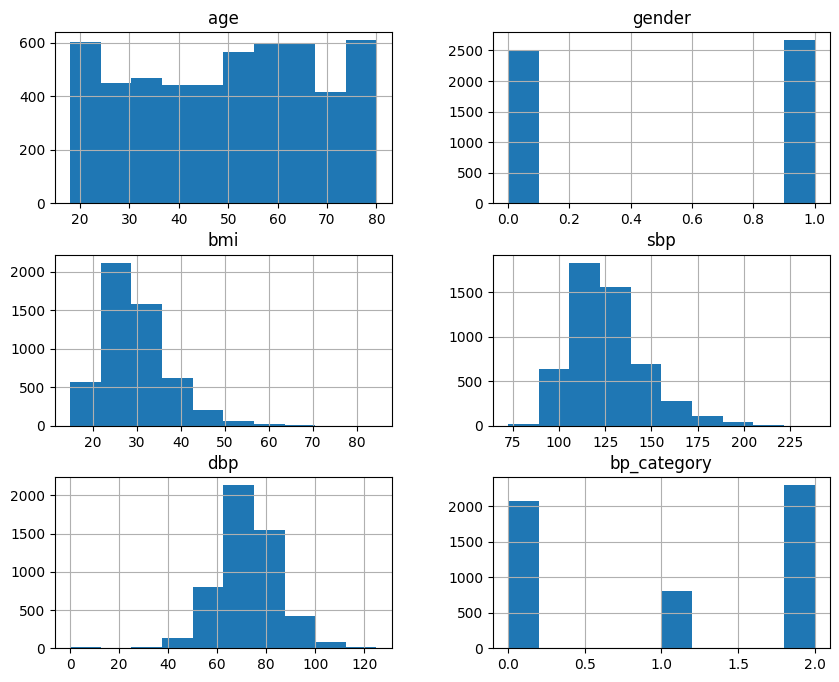

In [20]:
df.hist(figsize=(10,8))
plt.show()

#### Histogram Observations

- The distribution plots show how the key features are spread across the dataset. 
- Age appears to be fairly spread out across adult participants, indicating a diverse sample. 
- BMI values are mostly concentrated in the range of 20 to 35, with some higher values indicating overweight or obese individuals
- Systolic blood pressure (SBP) is a right‑skewed, indicating individuals with elevated and hypertensive readings.
- Diastolic blood pressure (DBP) looks more symmetrical, with slightly lower values in older participants, which is consistent with known age‑related vascular changes.



### BP Distributions by Class

#### Boxplot: SBP vs BP Cat

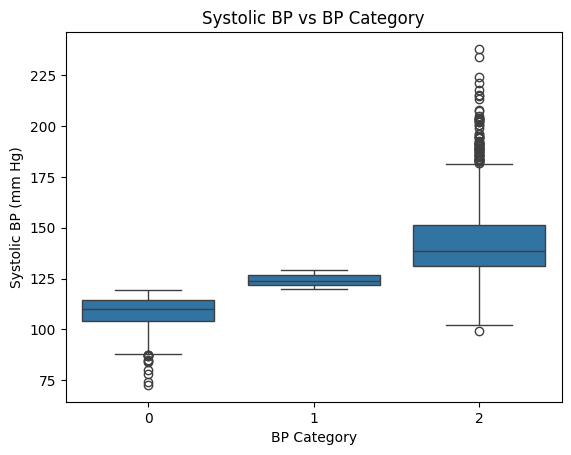

In [21]:
sns.boxplot(x="bp_category", y="sbp", data=df)
plt.title("Systolic BP vs BP Category")
plt.xlabel("BP Category")
plt.ylabel("Systolic BP (mm Hg)")
plt.show()

#### Boxplot: SBP vs BP Cat

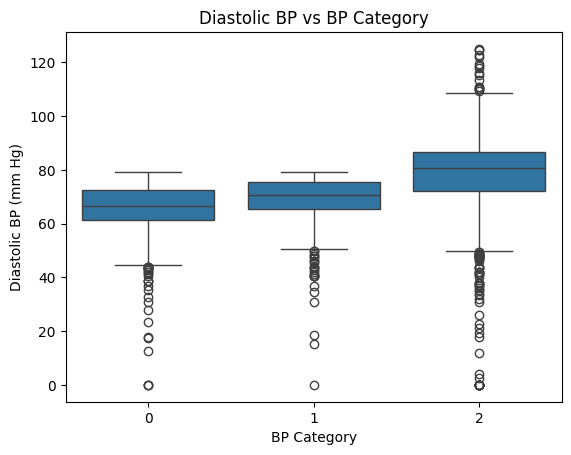

In [22]:
sns.boxplot(x="bp_category", y="dbp", data=df)
plt.title("Diastolic BP vs BP Category")
plt.xlabel("BP Category")
plt.ylabel("Diastolic BP (mm Hg)")
plt.show()

### Blood Pressure vs Category Analysis

- The boxplots reveal clear separation between the bp categories
- sbp increases steadily from normal to elevated to hypertension (with greater spread among hypertensive people)
- dbp shows a similar upward trend (but lesser than sbp) across the categories
- hypertension cases are displaying higher median values and mroe variability
- this suggests that sbp is the primary driver for category separation while dbp provides extra values
 

### BMI vs BP Category

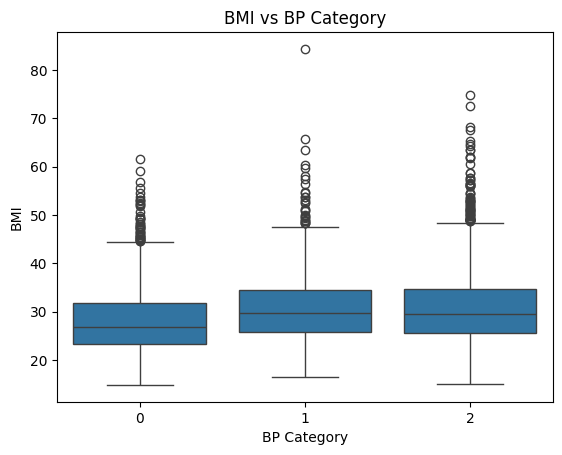

In [23]:
sns.boxplot(x="bp_category", y="bmi", data=df)
plt.title("BMI vs BP Category")
plt.xlabel("BP Category")
plt.ylabel("BMI")
plt.show()

#### Observation:

- BMI tends to increase with higher bp categories indicating a positive relation between body mass and hypertension risk


### Age vs BP Category

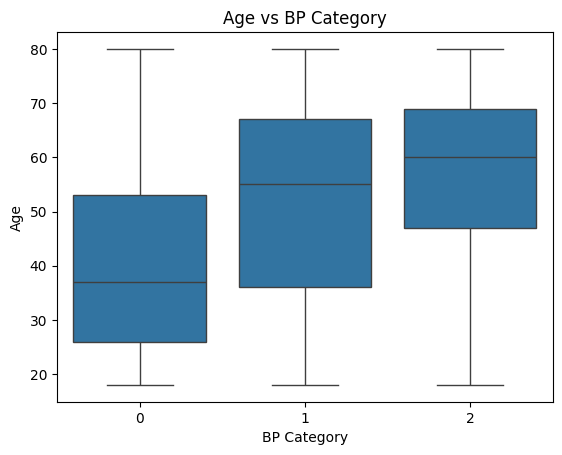

In [24]:
sns.boxplot(x="bp_category", y="age", data=df)
plt.title("Age vs BP Category")
plt.xlabel("BP Category")
plt.ylabel("Age")
plt.show()

#### Observation:

- Age also shows a clear upward trend across categories with hypertension indication in the elderlies 


### Correlation Heatmap

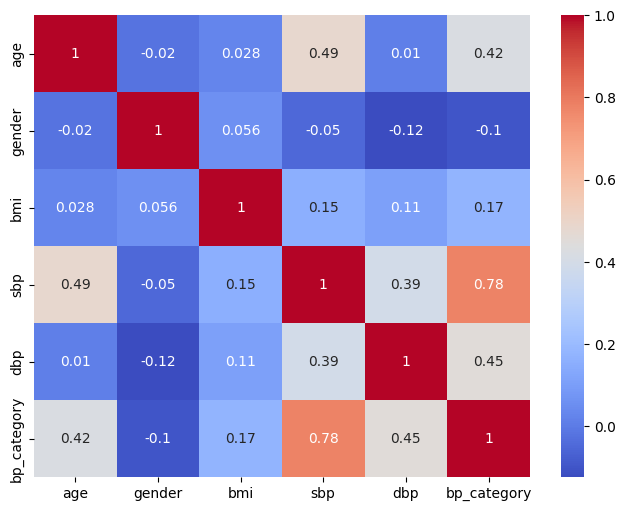

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Heatmap Observations


The correlation heatmap highlights relationships between numerical features and blood pressure category

- Systolic and diastolic blood pressure show the strongest positive correlation with the response variable
- Age and BMI display moderate positive correlations with elevated blood pressure risk with age
- Gender shows relatively weak correlation, indicating a smaller direct influence compared to age and bmi

These correlations further justify the selected feature set and support the subsequent modeling approach



### EDA Insights


Exploratory data analysis confirms that the dataset is well‑structured and clinically meaningful.

Key insights include:
- Clear and interpretable separation of all the blood pressure categories
- Systolic bp has the strongest influence and diastolic complements it
- Age and BMI contribute to increased blood pressure risk.
- Class imbalance is present and reflects real‑world population distributions.


## Feature Engineering

In [26]:
df.head()

,age,gender,bmi,sbp,dbp,bp_category
0,66.0,1,31.7,202.000000,62.000000,2
1,18.0,0,21.5,111.333333,73.333333,0
2,66.0,1,23.7,141.000000,77.000000,2
3,75.0,1,38.9,118.666667,66.666667,0
4,56.0,0,21.3,101.333333,66.666667,0


BMI categories
- Underweight: < 18.5 -------------> 0 
- Normal: 18.5 - 24.9 ------------> 1
- Overweight: 25.0 - 29.9 --------> 2
- Obesity: > 30.0 ----------------> 3
 

BP Ranges:

--------------------------- systolic mm Hg ------ Diastolic mm Hg </br>
normal -------------------- <120 ------&---------- <80 </br>
elevated ------------------ 120-129 ---&---------- <80 </br>
hypertension ------ >130 ------or--------- >=80 </br>


Categorizing BMI

In [27]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]
)


df["bmi_category"] = df["bmi_category"].cat.codes

df[["bmi", "bmi_category"]].head()


,bmi,bmi_category
0,31.7,3
1,21.5,1
2,23.7,1
3,38.9,3
4,21.3,1


Categorizing Age group (might remove later..)

In [28]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 45, 60, 100],
    labels=[0, 1, 2, 3],
    include_lowest=True
)

df["age_group"] = df["age_group"].cat.codes
df[["age", "age_group"]].head()

,age,age_group
0,66.0,3
1,18.0,0
2,66.0,3
3,75.0,3
4,56.0,2


### Setting High SBP and High DBP Flags

- dbp contributes but sbp majorly impacts
- so the thresholds must be:
    - High SBP: >= 130 mm Hg
    - High DBP: >= 80 mm Hg

In [30]:
# converting to  binary cols for elevated sbp and dbp as these cols will further help models to directly capture the re;evant threshold vals

df["high_sbp"] = df["sbp"].apply(lambda x: 1 if x >= 130 else 0)
df["high_dbp"] = df["dbp"].apply(lambda x: 1 if x >= 80 else 0)

df[["sbp", "dbp", "high_sbp", "high_dbp"]].head()

,sbp,dbp,high_sbp,high_dbp
0,202.000000,62.000000,1,0
1,111.333333,73.333333,0,0
2,141.000000,77.000000,1,0
3,118.666667,66.666667,0,0
4,101.333333,66.666667,0,0


#### Pulse Pressure Calculation

- Pulse pressure is directly related to cardiovascular risk
- so, high pulse pressure implies high cardiovascular risk (stiffness in arteries)
- pulse pressure = sbp - dbp

In [31]:
df["pulse_pressure"] = df["sbp"] - df["dbp"]
df[["sbp", "dbp"]].head()

,sbp,dbp
0,202.000000,62.000000
1,111.333333,73.333333
2,141.000000,77.000000
3,118.666667,66.666667
4,101.333333,66.666667


### Final set of Features/cols

In [32]:
feature_cols = [
    "age", "age_group",
    "gender",
    "bmi", "bmi_category",
    "sbp", "dbp",
    "high_sbp", "high_dbp",
    "pulse_pressure"
]

X = df[feature_cols]
y = df["bp_category"]

print(X.shape)
print(X.head())
print(y.value_counts())

(5176, 10)
    age  age_group  gender   bmi  bmi_category         sbp        dbp  \
0  66.0          3       1  31.7             3  202.000000  62.000000   
1  18.0          0       0  21.5             1  111.333333  73.333333   
2  66.0          3       1  23.7             1  141.000000  77.000000   
3  75.0          3       1  38.9             3  118.666667  66.666667   
4  56.0          2       0  21.3             1  101.333333  66.666667   

   high_sbp  high_dbp  pulse_pressure  
0         1         0      140.000000  
1         0         0       38.000000  
2         1         0       64.000000  
3         0         0       52.000000  
4         0         0       34.666667  
bp_category
2    2292
0    2077
1     807
Name: count, dtype: int64


### Feature Engineerning Summary

- Categorized BMI and Age to make their values more usable
- Created binary cols for elevated SBP and DBP
- Created pulse pressure col to consider cardiovaslucar risks
- Kept both original and feature engineered cols to make it diverse and model can conclude through different patterns
- These features will now help to get more threshold based effects on blood pressure risk

## Training/Testing ML Models

In [34]:
# since the response column is categorical, I will be using Classification Algorithms to train, test and evaluate
# train, test, split
X = df[feature_cols]
y = df["bp_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# handling the imbalance here by normalizing (converting it from 0-1)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

bp_category
2    0.442754
0    0.401208
1    0.156039
Name: proportion, dtype: float64
bp_category
2    0.443050
0    0.401544
1    0.155405
Name: proportion, dtype: float64


In [35]:
# creating helper this time to work with (train-test-evaluate) all the classification models

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
   
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
   
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
   
    return {
        "Model": name,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "model_obj": model
    }

#### Logistic Regression Model

In [36]:
lr = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial"
)

results_lr = evaluate_model(
    "Logistic Regression",
    lr,
    X_train, X_test, y_train, y_test
)

C:\Users\eshik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       416
           1       0.95      0.98      0.97       161
           2       1.00      0.99      1.00       459

    accuracy                           0.99      1036
   macro avg       0.98      0.99      0.98      1036
weighted avg       0.99      0.99      0.99      1036



C:\Users\eshik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Random Forest Model

In [37]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

results_rf = evaluate_model(
    "Random Forest",
    rf,
    X_train, X_test, y_train, y_test
)


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       416
           1       1.00      1.00      1.00       161
           2       1.00      1.00      1.00       459

    accuracy                           1.00      1036
   macro avg       1.00      1.00      1.00      1036
weighted avg       1.00      1.00      1.00      1036



#### Gradient Boosting Model

In [39]:
gb = GradientBoostingClassifier(
    random_state=42
)

results_gb = evaluate_model(
    "Gradient Boosting",
    gb,
    X_train, X_test, y_train, y_test
)


Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       416
           1       1.00      1.00      1.00       161
           2       1.00      1.00      1.00       459

    accuracy                           1.00      1036
   macro avg       1.00      1.00      1.00      1036
weighted avg       1.00      1.00      1.00      1036



#### XGBoost Model

In [40]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

results_xgb = evaluate_model(
    "XGBoost",
    xgb,
    X_train, X_test, y_train, y_test
)


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       416
           1       1.00      1.00      1.00       161
           2       1.00      1.00      1.00       459

    accuracy                           1.00      1036
   macro avg       1.00      1.00      1.00      1036
weighted avg       1.00      1.00      1.00      1036



#### Comparing models

In [41]:
results_df = pd.DataFrame([
    results_lr, results_rf, results_gb, results_xgb
]).drop(columns=["model_obj"])

results_df

,Model,Macro F1,Weighted F1
0,Logistic Regression,0.984481,0.989449
1,Random Forest,1.000000,1.000000
2,Gradient Boosting,1.000000,1.000000
3,XGBoost,1.000000,1.000000


#### Selecting the best model

In [42]:
best_result = max(
    [results_lr, results_rf, results_gb, results_xgb],
    key=lambda x: x["Macro F1"]
)

best_model = best_result["model_obj"]

print("Best Model:", best_result["Model"])
print("Macro F1:", best_result["Macro F1"])
print("Weighted F1:", best_result["Weighted F1"])

Best Model: Random Forest
Macro F1: 1.0
Weighted F1: 1.0


### Confusion Matrix

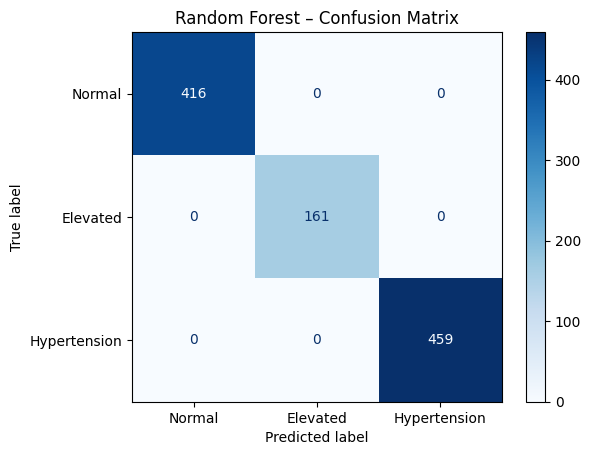

In [43]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues",
    display_labels=["Normal", "Elevated", "Hypertension"]
)

plt.title(f"{best_result['Model']} – Confusion Matrix")
plt.show()

### Model Explanation

- All the models are achieving high accuracy and F1-scores across all bp categories
- This kind of behavior is expected as the target variable was constructed directly from sbp and dbp values, which are also included as input features
- as a result, the models are learning clear decision boundaries based on clinically established thresholds rather than finding implicit or hidden patterns
- This is totally like real-world decision-making, where bp categories are assigned based on measured values
- the confusion matrix shows that most misclassifications occur between adjacent categories (Normal vs Elevated, Elevated vs Hypertension), which is clinically reasonable
- Extreme misclassifications are rare in this c ase
- as a future task, sbp and dbp can be completely excluded from input features, to allow the model to predict bp categories using only demographic and other important information gathered
- This would represent a more challenging prediction task focusing on risk estimation rather than classification.

## Creating .pkl file from the best performing model

In [48]:
# since Random Forest model had the highest Macro-F1 and performed best, creating pkl model using it
# with open("../models/bp_model.pkl", "wb") as f:
#     pickle.dump(rf, f)

# need to save feature order
model_package = {
    "model_name": best_result["Model"],
    "model": best_model,
    "feature_columns": feature_cols
}

with open("../models/bp_model.pkl", "wb") as f:
    pickle.dump(model_package, f)

In [50]:
# using the pkl model
# first loading

with open("../models/bp_model.pkl", "rb") as f:
    bp_package = pickle.load(f)

bp_model = bp_package["model"]
bp_features = bp_package["feature_columns"]


In [55]:
# prediction function

def predict_bp(age, gender, bmi, sbp, dbp):
    
    # Feature engineering (same as training)
    bmi_category = 0
    if bmi < 18.5:
        bmi_category = 0
    elif bmi < 25:
        bmi_category = 1
    elif bmi < 30:
        bmi_category = 2
    else:
        bmi_category = 3

    high_sbp = 1 if sbp >= 130 else 0
    high_dbp = 1 if dbp >= 80 else 0
    pulse_pressure = sbp - dbp


    if age < 30:
        age_group = 0
    elif age < 45:
        age_group = 1
    elif age < 60:
        age_group = 2
    else:
        age_group = 3

    

    features = pd.DataFrame([{
        "age": age,
        "age_group": age_group,
        "gender": gender,
        "bmi": bmi,
        "bmi_category": bmi_category,
        "sbp": sbp,
        "dbp": dbp,
        "high_sbp": high_sbp,
        "high_dbp": high_dbp,
        "pulse_pressure": pulse_pressure
    }])

    # predict
    prediction = bp_model.predict(features)[0]
    probability = bp_model.predict_proba(features)[0]


    class_map = {
        0: "Normal",
        1: "Elevated",
        2: "Hypertension"
    }

    return {
        "predicted_class": int(prediction),
        "predicted_label": class_map[prediction],
        "probabilities": {
            "Normal": probability[0],
            "Elevated": probability[1],
            "Hypertension": probability[2]
        }
    }


    # return prediction, probability

In [56]:
# testing it

# first for hypertension
result = predict_bp(
    age=55,
    gender=1,
    bmi=32,
    sbp=145,
    dbp=92
)
print(result)

{'predicted_class': 2, 'predicted_label': 'Hypertension', 'probabilities': {'Normal': np.float64(0.0), 'Elevated': np.float64(0.0), 'Hypertension': np.float64(1.0)}}


In [57]:
# testing it

# now for normal
result = predict_bp(
    age=25,
    gender=0,
    bmi=22,
    sbp=115,
    dbp=72
)
print(result)

{'predicted_class': 0, 'predicted_label': 'Normal', 'probabilities': {'Normal': np.float64(1.0), 'Elevated': np.float64(0.0), 'Hypertension': np.float64(0.0)}}


In [58]:
# testing it

# now for elevated
result = predict_bp(
    age=40,
    gender=1,
    bmi=27,
    sbp=125,
    dbp=78
)
print(result)

{'predicted_class': 1, 'predicted_label': 'Elevated', 'probabilities': {'Normal': np.float64(0.0), 'Elevated': np.float64(1.0), 'Hypertension': np.float64(0.0)}}


## References

- Whelton, P. K., Carey, R. M., Aronow, W. S., Casey, D. E., Collins, K. J., Dennison Himmelfarb, C., … Wright, J. T. (2018). 2017 ACC/AHA/AAPA/ABC/ACPM/AGS/APhA/ASH/ASPC/NMA/PCNA guideline for the prevention, detection, evaluation, and management of high blood pressure in adults. Circulation, 138(17), e484–e594. Retrieved from https://www.ahajournals.org/doi/10.1161/CIR.0000000000000590
- Tang, K. S., Jones, J. E., Fan, W., & Wong, N. D. (2025). Prevalence and mortality trends of hypertension subtypes among US adults: NHANES analysis. American Journal of Hypertension, 38(5), 303–312. Retrieved from https://doi.org/10.1093/ajh/hpaf010
- Msokar, S., Davydov, R., & Davydov, V. (2026). Interpretable photoplethysmography feature engineering for multi‑class blood pressure staging. Computers, 15(4), 209. Retrieved from https://doi.org/10.3390/computers15040209
- Valerio, A., Demarchi, D., O’Flynn, B., Motto Ros, P., & Tedesco, S. (2024). Development of a personalized multiclass classification model to detect blood pressure variations. Sensors, 24(11), 3697. Retrieved from https://doi.org/10.3390/s24113697
- Elperin, D. T., Pelter, M. A., Deamer, R. L., & Burchette, R. J. (2014). Risk factors associated with uncontrolled hypertension. Journal of Clinical Hypertension, 16(2), 149–154. Retrieved from https://doi.org/10.1111/jch.12259
- Reading .xpt files: https://pandas.pydata.org/docs/reference/api/pandas.read_sas.html
- BMI categories: https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html 
- Blood Pressure Levels: https://www.heart.org/en/health-topics/high-blood-pressure
- Pulse Pressure: https://my.clevelandclinic.org/health/body/21629-pulse-pressure

